In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def generate_data(num_samples):
    X = np.random.randn(num_samples,1) * 10
    y = 3 * X + 7 +np.random.randn(num_samples,1)
    return X, y

In [5]:
X, y = generate_data(50)

In [6]:
def compute_loss(y_true, y_pred):
    return np.mean((y_true-y_pred)**2)

In [22]:
class RMSProp:
    def __init__(self, parameters, epochs=100, lr=0.01, beta=0.9, epsilon=1e-8, print_on_step=None):
        self.theta_ = parameters
        self.n_epochs = epochs
        self.lr = lr
        self.beta = beta
        self.epsilon = epsilon
        self.print_on_step = print_on_step

        self.MASG = np.zeros(self.theta_.shape)
        self.parameter_pairs = [self.theta_.copy().reshape(-1)]
        self.loss_history = []
    def optimize(self, X, y):
        n_points, n_features = X.shape
        X = np.c_[np.ones((n_points,1)),X]
        for epoch in range(1,1+self.n_epochs):

            y_pred = np.dot(X, self.theta_)
            error = y - y_pred
            loss = compute_loss(y, y_pred)

            gradient = - (2/n_points) * np.dot(X.T,error)
            self.MASG = self.beta * self.MASG + (1-self.beta) * np.power(gradient,2)

            self.theta_ -= self.lr/np.sqrt(self.MASG+ self.epsilon) * gradient
            self.parameter_pairs.append(self.theta_.copy().reshape(-1))
            
            if self.print_on_step:
                if epoch%self.print_on_step==0:
                    print(f"Epoch: {epoch}, Loss: {loss:.4f}")

            self.loss_history.append(loss)



In [23]:
theta_ = np.random.randn(X.shape[1]+1,1)

In [24]:
theta_

array([[-1.71268798],
       [-0.66451186]])

In [25]:
rmsprop = RMSProp(theta_,epochs=100, lr=0.1, print_on_step=10)

In [26]:
rmsprop.optimize(X,y)

Epoch: 10, Loss: 635.5846
Epoch: 20, Loss: 262.1967
Epoch: 30, Loss: 93.2325
Epoch: 40, Loss: 30.7339
Epoch: 50, Loss: 15.1436
Epoch: 60, Loss: 10.1444
Epoch: 70, Loss: 6.4100
Epoch: 80, Loss: 3.6606
Epoch: 90, Loss: 1.9367
Epoch: 100, Loss: 1.0833


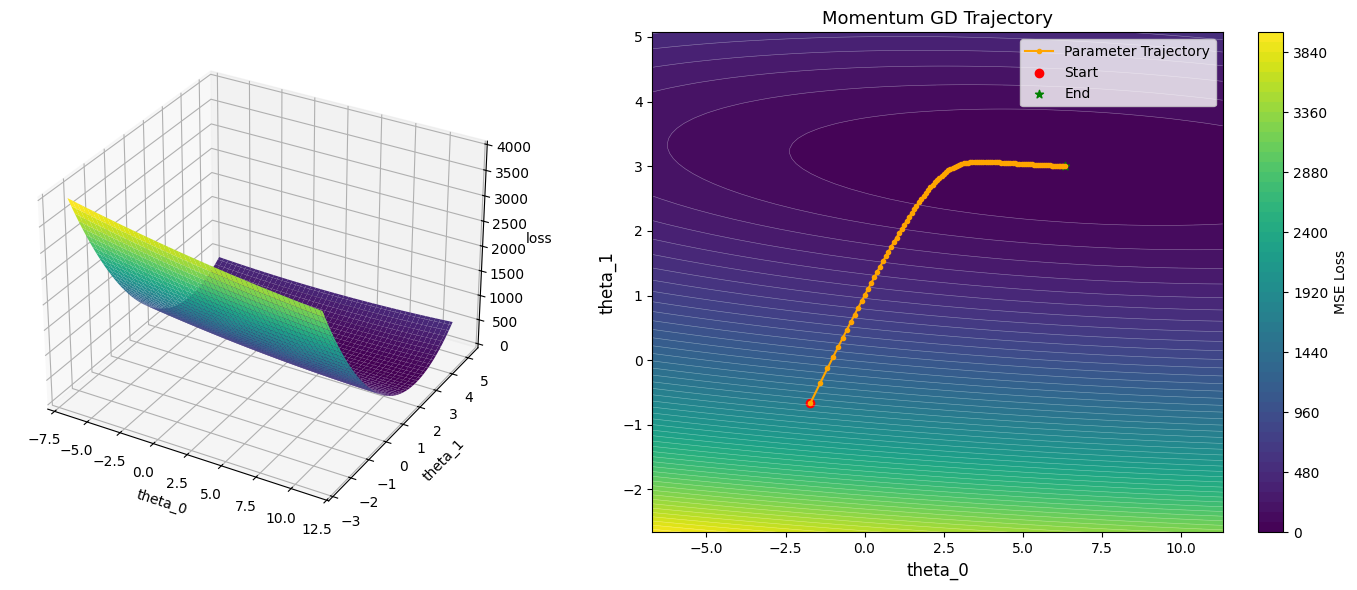

In [28]:
pairs = np.array(rmsprop.parameter_pairs)  
n_points = X.shape[0]
X_aug = np.c_[np.ones((n_points, 1)), X]  

theta0_vals = np.linspace(pairs[:, 0].min() - 5, pairs[:, 0].max() + 5, 100)
theta1_vals = np.linspace(pairs[:, 1].min() - 2, pairs[:, 1].max() + 2, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)  

Theta_grid = np.column_stack([T0.ravel(), T1.ravel()])

Y_preds = X_aug @ Theta_grid.T

Loss = np.mean((y - Y_preds) ** 2, axis=0).reshape(T0.shape)

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(121, projection='3d')

ax1.plot_surface(T0, T1, Loss, cmap='viridis')
ax1.set_xlabel('theta_0')
ax1.set_ylabel('theta_1')
ax1.set_zlabel('loss')

ax2 = fig.add_subplot(122)

contour_filled = ax2.contourf(T0, T1, Loss, levels=50, cmap='viridis')
ax2.contour(T0, T1, Loss, levels=60, colors='white', linewidths=0.4, alpha=0.4)
plt.colorbar(contour_filled, ax=ax2, label='MSE Loss')


ax2.plot(pairs[:, 0], pairs[:, 1], color='orange', linewidth=1.5, marker='o', markersize=3, label='Parameter Trajectory')

ax2.scatter(*pairs[0],  color='red', label='Start')
ax2.scatter(*pairs[-1], color='green',   marker='*', label='End')

ax2.set_xlabel('theta_0',   fontsize=12)
ax2.set_ylabel('theta_1', fontsize=12)
ax2.set_title('Momentum GD Trajectory', fontsize=13)
ax2.legend()
plt.tight_layout()
plt.show()

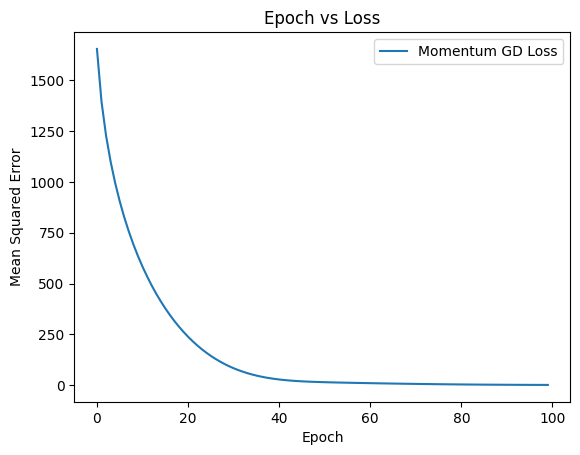

In [29]:
plt.plot(rmsprop.loss_history,label="Momentum GD Loss")
plt.title("Epoch vs Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()